# 09 — Wildfire 30-day Risk Prediction

**Phase 4, Step 3** — the end-to-end forward prediction.

Combines:
- `data/processed/weather_forecast.csv` (Phase 2.4)
- `data/interim/weather_daily_clean.csv` (Phase 2.1 — as the recent historical tail)
- `data/interim/{ndvi,roads,population,lightning,cities_reference}.csv` (Phase 1)
- `models/wildfire/classifier/*.joblib` (Phase 4.2)
- `models/wildfire/regressor/*.joblib` (Phase 4.2)

...into:

**Output:** `data/processed/wildfire_risk_forecast.csv`

| Column | Meaning |
|---|---|
| `City` | |
| `anchor_date` | Last observed date (= forecast anchor) |
| `forecast_date` | `anchor_date + horizon_days` |
| `horizon_days` | 1..30 |
| `fire_probability` | Calibrated classifier probability of ≥1 fire on that day |
| `risk_category` | `low` (< 0.10) / `moderate` (< 0.25) / `high` (< 0.50) / `very_high` |
| `expected_fire_count` | Regressor prediction (non-negative float) |

---

## Architectural note — why not just bolt a classifier onto the forecast?

The wildfire classifier was trained on ~35 predictors (weather + drought
index + heatwave flags + wind spread + NDVI + human activity + lightning +
city dummies). The weather forecast only provides 5 of those — the other 30
need to be rebuilt at prediction time.

To handle this cleanly:

1. **Concatenate a 90-day historical tail** onto the 30-day forecast so that
   stateful features (drought index, heatwave run-length, wind-spread
   persistence) have correct warm-up state.
2. **Fill forecast-missing columns with per-city DOY climatology** — for
   variables not predicted (humidity, soil T, etc.) the best prior is the
   historical typical value for that day-of-year.
3. **Rebuild the derived features** on the combined history + forecast frame
   using the exact same `src.wildfire.features` functions the training data
   used.
4. **Slice out the forecast-only rows** for scoring.
5. **Align columns** to the model's `feature_names_in_` before `predict_proba`.

This is more careful than the typical tutorial — it's what production systems
do to avoid "works on training data, fails on new data" bugs.

## 1. Setup

In [9]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

from src.wildfire import predict as wfp
from src.utils.config import PROCESSED_DIR, INTERIM_DIR, MODELS_DIR
from src.utils.logging_utils import get_logger
logger = get_logger("nb.09_wildfire_prediction")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Run the prediction pipeline

In [11]:
risk = wfp.predict_wildfire_risk_30day()
print(f"Shape: {risk.shape}")
print(f"Anchor: {risk['anchor_date'].iloc[0].date()}")
print(f"Forecast window: {risk['forecast_date'].min().date()} -> {risk['forecast_date'].max().date()}")
risk.head(10)

18:59:01 | INFO    | src.wildfire.predict | ========================================================================
18:59:01 | INFO    | src.wildfire.predict | PHASE 4.3 - 30-day wildfire risk prediction
18:59:01 | INFO    | src.wildfire.predict | ========================================================================
18:59:01 | INFO    | src.wildfire.predict | Filled 17 missing forecast columns via DOY climatology
18:59:01 | INFO    | src.wildfire.predict | Combined tail + forecast: 605 rows (455 tail + 150 forecast)
18:59:01 | INFO    | src.wildfire.features | Added drought_index and dry_days_run
18:59:01 | INFO    | src.wildfire.features | Heatwave thresholds (p90): {'Baku': 20.89, 'Ganja': 22.08, 'Guba': 18.62, 'Lankaran': 20.29, 'Zaqatala': 20.26}
18:59:01 | INFO    | src.wildfire.features | Added dir_persistence and wind_spread (window=3d)
18:59:01 | INFO    | src.wildfire.features | Added ndvi + ndvi_anomaly (100.0% non-null after ffill)
18:59:02 | INFO    | src.wildfire.featu

Shape: (150, 7)
Anchor: 2026-04-18
Forecast window: 2026-04-19 -> 2026-05-18


,City,anchor_date,forecast_date,horizon_days,fire_probability,risk_category,expected_fire_count
0,Baku,2026-04-18,2026-04-19,1,0.652079,very_high,0.280275
1,Baku,2026-04-18,2026-04-20,2,0.545214,very_high,0.208348
2,Baku,2026-04-18,2026-04-21,3,0.613866,very_high,0.267864
3,Baku,2026-04-18,2026-04-22,4,0.622065,very_high,0.295214
4,Baku,2026-04-18,2026-04-23,5,0.568803,very_high,0.284397
5,Baku,2026-04-18,2026-04-24,6,0.594703,very_high,0.303316
6,Baku,2026-04-18,2026-04-25,7,0.596381,very_high,0.301776
7,Baku,2026-04-18,2026-04-26,8,0.533680,very_high,0.215545
8,Baku,2026-04-18,2026-04-27,9,0.674941,very_high,0.363671
9,Baku,2026-04-18,2026-04-28,10,0.662481,very_high,0.350935


## 3. Summary per city

In [12]:
summary = (
    risk.groupby("City").agg(
        mean_probability   = ("fire_probability", "mean"),
        max_probability    = ("fire_probability", "max"),
        median_probability = ("fire_probability", "median"),
        days_high_or_above = ("risk_category", lambda s: (s.isin(["high","very_high"])).sum()),
        total_expected_fires = ("expected_fire_count", "sum"),
    ).round(3).sort_values("mean_probability", ascending=False)
)
summary

,mean_probability,max_probability,median_probability,days_high_or_above,total_expected_fires
City,,,,,
Baku,0.570,0.675,0.590,30,8.201
Ganja,0.287,0.461,0.239,14,1.255
Guba,0.185,0.398,0.161,6,2.781
Zaqatala,0.143,0.264,0.119,3,0.505
Lankaran,0.132,0.269,0.110,1,1.001


## 4. Risk timeline per city

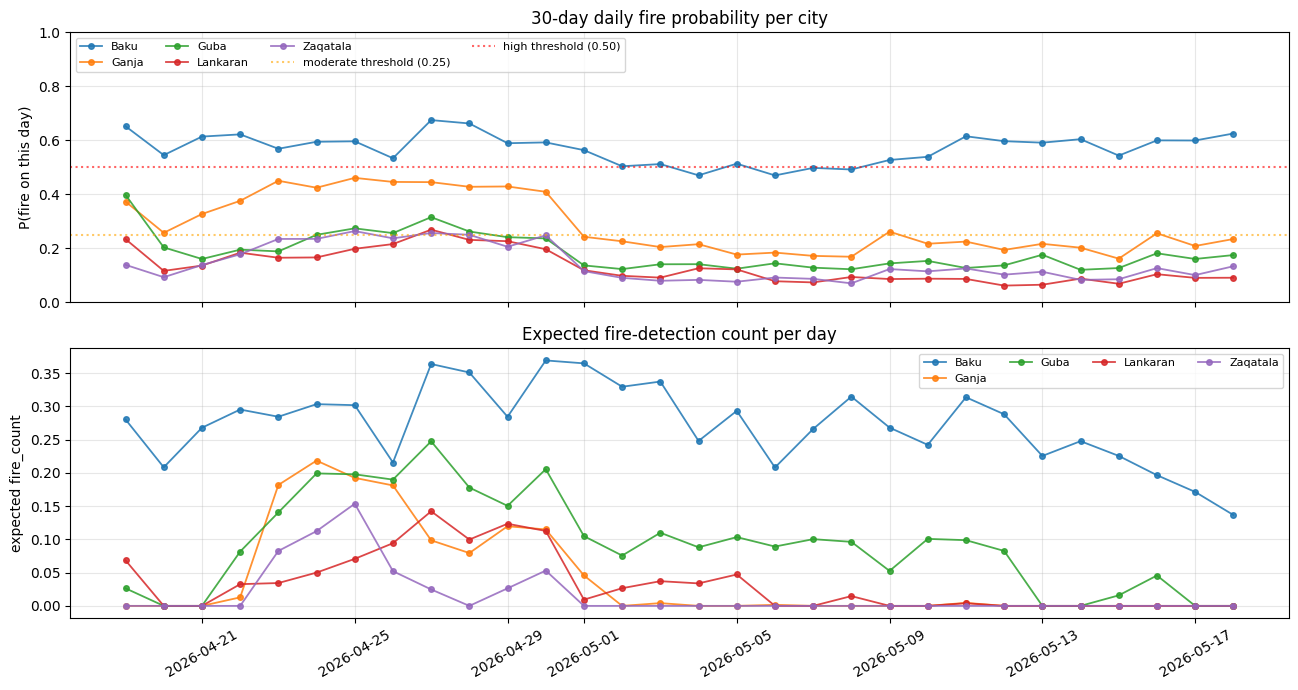

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

for city, g in risk.groupby("City"):
    g = g.sort_values("forecast_date")
    ax[0].plot(g["forecast_date"], g["fire_probability"], "o-", lw=1.3, ms=4, alpha=0.85, label=city)
    ax[1].plot(g["forecast_date"], g["expected_fire_count"], "o-", lw=1.3, ms=4, alpha=0.85, label=city)

ax[0].axhline(0.25, ls=":", color="orange", alpha=0.6, label="moderate threshold (0.25)")
ax[0].axhline(0.50, ls=":", color="red", alpha=0.6, label="high threshold (0.50)")
ax[0].set_ylabel("P(fire on this day)")
ax[0].set_title("30-day daily fire probability per city")
ax[0].legend(ncol=4, fontsize=8, loc="upper left")
ax[0].grid(alpha=0.3)
ax[0].set_ylim(0, 1)

ax[1].set_ylabel("expected fire_count")
ax[1].set_title("Expected fire-detection count per day")
ax[1].grid(alpha=0.3)
ax[1].legend(ncol=4, fontsize=8)

plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

## 5. Risk-category heatmap

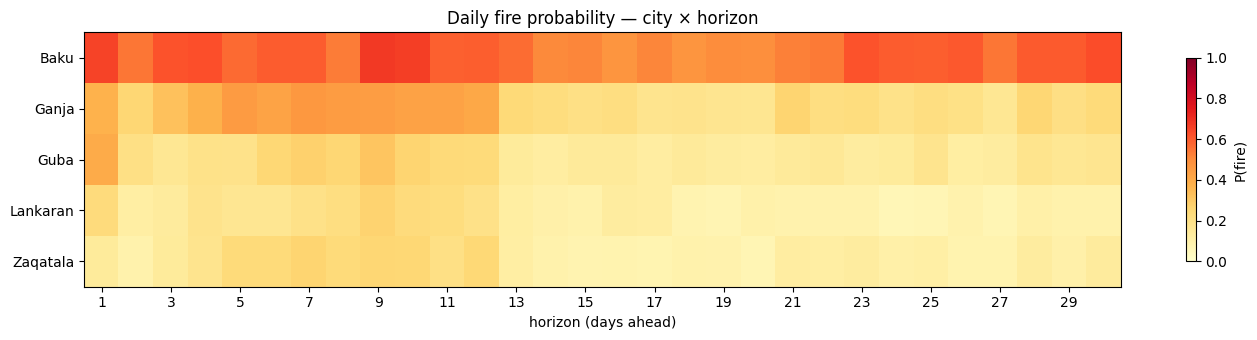

In [14]:
pivot = risk.pivot_table(index="City", columns="horizon_days", values="fire_probability")
fig, ax = plt.subplots(figsize=(14, 3.5))
im = ax.imshow(pivot.values, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(0, 30, 2))
ax.set_xticklabels(pivot.columns[::2])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("horizon (days ahead)"); ax.set_title("Daily fire probability — city × horizon")
plt.colorbar(im, ax=ax, shrink=0.8, label="P(fire)")
plt.tight_layout(); plt.show()

## 6. City-level risk summary text

In [15]:
for _, row in summary.iterrows():
    city = row.name
    m = row["mean_probability"]
    hi_days = int(row["days_high_or_above"])
    exp = row["total_expected_fires"]
    if m >= 0.5:
        verdict = "VERY HIGH — expect fires on most days"
    elif m >= 0.25:
        verdict = "HIGH — fires likely on several days"
    elif m >= 0.10:
        verdict = "MODERATE — some elevated-risk days"
    else:
        verdict = "LOW — baseline conditions"
    print(f"{city:10s}  {verdict}")
    print(f"           mean P={m:.2f}, {hi_days} of 30 days are high/very-high, ~{exp:.1f} total expected detections")

Baku        VERY HIGH — expect fires on most days
           mean P=0.57, 30 of 30 days are high/very-high, ~8.2 total expected detections
Ganja       HIGH — fires likely on several days
           mean P=0.29, 14 of 30 days are high/very-high, ~1.3 total expected detections
Guba        MODERATE — some elevated-risk days
           mean P=0.18, 6 of 30 days are high/very-high, ~2.8 total expected detections
Zaqatala    MODERATE — some elevated-risk days
           mean P=0.14, 3 of 30 days are high/very-high, ~0.5 total expected detections
Lankaran    MODERATE — some elevated-risk days
           mean P=0.13, 1 of 30 days are high/very-high, ~1.0 total expected detections


## 7. What drives a particular high-risk day?

For a single forecast day we reconstruct its feature vector and inspect
which variables pushed the probability up. This is helpful for sanity
checking individual predictions.

In [16]:
import joblib, json as _json
from src.wildfire.predict import build_forecast_feature_frame, _align_columns_to_model
from src.wildfire.features import (
    add_drought_index, add_heatwave_indicator, add_wind_spread_factor,
    add_fuel_dryness, add_human_activity, add_lightning_climatology,
)

# Reuse the internals to get the feature frame once
fcst = pd.read_csv(PROCESSED_DIR / "weather_forecast.csv", parse_dates=["anchor_date","forecast_date"])
hist = pd.read_csv(INTERIM_DIR / "weather_daily_clean.csv", parse_dates=["date"])
if fcst["forecast_date"].dt.tz is not None:
    fcst["forecast_date"] = fcst["forecast_date"].dt.tz_localize(None)
    fcst["anchor_date"] = fcst["anchor_date"].dt.tz_localize(None)
if hist["date"].dt.tz is not None:
    hist["date"] = hist["date"].dt.tz_localize(None)

ndvi = pd.read_csv(INTERIM_DIR / "ndvi.csv")
roads = pd.read_csv(INTERIM_DIR / "roads.csv")
population = pd.read_csv(INTERIM_DIR / "population.csv")
lightning = pd.read_csv(INTERIM_DIR / "lightning.csv")
cities_all = pd.read_csv(INTERIM_DIR / "cities_reference.csv")
cities = cities_all[cities_all["City"].isin(hist["City"].unique())]

feats = build_forecast_feature_frame(fcst, hist, ndvi, roads, population, lightning, cities)
for city in cities["City"]:
    feats[f"city_{city}"] = (feats["City"] == city).astype(np.int8)

# Compare Baku h=1 vs Zaqatala h=1: what's different?
best = _json.loads((MODELS_DIR / "wildfire" / "best.json").read_text())
clf = joblib.load(best["classifier"]["path"])

X = feats.drop(columns=["City", "date"])
X_aligned = _align_columns_to_model(X, clf)
scaler = clf["scaler"] if isinstance(clf, dict) else None
model  = clf["clf"] if isinstance(clf, dict) else clf

# Per-feature contributions: coef * standardised_value (logistic only)
if hasattr(model, "coef_"):
    Xs = scaler.transform(X_aligned) if scaler is not None else X_aligned.values
    contrib = Xs * model.coef_[0]  # (n_samples, n_features)

    # Find a Baku day and a Zaqatala day at h=1
    meta = feats[["City", "date"]].reset_index(drop=True)
    for city in ("Baku", "Zaqatala"):
        idx = meta.index[(meta["City"] == city) & (meta["date"] == feats["date"].min())]
        if len(idx) == 0: continue
        i = idx[0]
        c = pd.Series(contrib[i], index=X_aligned.columns).sort_values(key=abs, ascending=False)
        print(f"\n=== {city}: top 10 feature contributions to log-odds ===")
        print(c.head(10).round(3).to_string())
else:
    print("Model isn't logistic; skipping coefficient analysis.")

18:59:31 | INFO    | src.wildfire.predict | Filled 17 missing forecast columns via DOY climatology
18:59:31 | INFO    | src.wildfire.predict | Combined tail + forecast: 605 rows (455 tail + 150 forecast)
18:59:31 | INFO    | src.wildfire.features | Added drought_index and dry_days_run
18:59:31 | INFO    | src.wildfire.features | Heatwave thresholds (p90): {'Baku': 20.89, 'Ganja': 22.08, 'Guba': 18.62, 'Lankaran': 20.29, 'Zaqatala': 20.26}
18:59:31 | INFO    | src.wildfire.features | Added dir_persistence and wind_spread (window=3d)
18:59:31 | INFO    | src.wildfire.features | Added ndvi + ndvi_anomaly (100.0% non-null after ffill)
18:59:31 | INFO    | src.wildfire.features | Added human_access_road_meters, pop_density, human_activity_score
18:59:32 | INFO    | src.wildfire.features | Added lightning_thunder_hours (monthly per-city climatology)
18:59:32 | INFO    | src.wildfire.predict | Forecast feature frame: (150, 39)
18:59:32 | INFO    | src.wildfire.predict |   Dropped 6 extra colu


=== Baku: top 10 feature contributions to log-odds ===
year                           -0.504
ndvi                            0.470
pop_density                     0.454
month                           0.443
wind_gusts_10m_max              0.396
doy                            -0.379
cloud_cover_mean                0.274
wind_speed_10m_max             -0.237
vapour_pressure_deficit_mean    0.231
dew_point_2m_mean              -0.215

=== Zaqatala: top 10 feature contributions to log-odds ===
pop_density               -0.509
year                      -0.504
city_Zaqatala              0.467
month                      0.443
lightning_thunder_hours   -0.436
doy                       -0.379
ndvi_anomaly              -0.360
precipitation_sum         -0.257
wind_gusts_10m_max        -0.234
temperature_2m_max         0.226


## 8. Honest caveats for end users

- **Forecast skill decays.** Weather temperature has ~2 week useful horizon;
  precipitation ~5 days. Beyond that, our predictors converge to climatology,
  so fire probabilities beyond ~day 14 reflect *seasonal* risk more than
  genuine day-to-day forecasting.
- **Base rates are per-city.** Baku's high probabilities reflect its high
  historical fire-day rate (27%). A "very_high" label for Baku is less alarming
  than the same label for Zaqatala (base rate 8%).
- **Label noise.** Some FIRMS hotspots in Baku are industrial flaring despite
  our `type=0` filter. A rigorous production deployment would integrate a
  gas-flare mask.
- **Trained on 2020-2023, tested on 2024.** If 2025-2026 fire dynamics differ
  meaningfully (e.g. policy changes on agricultural burning), recalibrate.

## 9. Persisted artefact

In [17]:
p = PROCESSED_DIR / "wildfire_risk_forecast.csv"
print(f"  {p.name:35s} {p.stat().st_size/1024:7.2f} KB")
print(f"  Rows: {len(pd.read_csv(p)):,}")

  wildfire_risk_forecast.csv            10.83 KB
  Rows: 150


---

**Phase 4 (Wildfire System) ✅ COMPLETE.**

Next and final: `10_final_analysis.ipynb` — the data-driven report that
answers the 5 project questions, followed by `README.md` and then the
FastAPI + dashboard web app.